# Re-classify with all 5 detectors

We filtered the LLM fakes through a **dual discriminator**: a fake survives only if it fooled **both BiLSTM AND DistilBERT**. Now we throw **all 5 classifiers** at this hard-mode set to see how each one degrades.

**The 3 rounds of fakes:**
1. **Markov 3-gram fakes**
2. **LLM fakes**
3. **Adversarial LLM fakes** (filtered through BiLSTM + DistilBERT ensemble) > this notebook

We compute test accuracy for each classifier on each round and produce the 3-way comparison.

**Required files:**
- All the standard files `data_loader.py`, `tokenizer_util.py`, `06_compare_results.py`.
- All trained models `model_01_logreg.joblib`, `model_02_mlp.pt` + `tokenizer_02.json`..
- The adversarial fakes from notebook 1: `fake_tweets_adversarial.json`..


In [1]:
# Install dependencies
!pip install torch transformers scikit-learn pandas matplotlib joblib --quiet

In [ ]:
import os
import shutil

# Create the folder
os.makedirs("model_05_distilbert", exist_ok=True)

# Move all DistilBERT-related files into it
distilbert_files = [
    "config.json",
    "model.safetensors",
    "tokenizer.json",
    "tokenizer_config.json",

]

moved = []
for f in distilbert_files:
    if os.path.exists(f):
        shutil.move(f, f"model_05_distilbert/{f}")
        moved.append(f)

print(f"Moved {len(moved)} files into model_05_distilbert/")
print("Contents:", os.listdir("model_05_distilbert"))

Moved 4 files into model_05_distilbert/
Contents: ['model.safetensors', 'config.json', 'tokenizer_config.json', 'tokenizer.json']


In [5]:
# To if check that all needed files are present
import os
needed = [
    "data_loader.py", "tokenizer_util.py", "06_compare_results.py",
    "tweets.csv", "fake_tweets_3.json", "fake_tweets_adversarial.json",
    "model_01_logreg.joblib",
    "model_02_mlp.pt", "tokenizer_02.json",
    "model_03_lstm.pt", "tokenizer_03.json",
    "model_04_transformer.pt", "tokenizer_04.json",
]
for f in needed:
    print(f"{'✓' if os.path.exists(f) else '✗'}  {f}")
print(f"{'✓' if os.path.isdir('model_05_distilbert') else '✗'}  model_05_distilbert/")

✓  data_loader.py
✓  tokenizer_util.py
✓  06_compare_results.py
✓  tweets.csv
✓  fake_tweets_3.json
✓  fake_tweets_adversarial.json
✓  model_01_logreg.joblib
✓  model_02_mlp.pt
✓  tokenizer_02.json
✓  model_03_lstm.pt
✓  tokenizer_03.json
✓  model_04_transformer.pt
✓  tokenizer_04.json
✓  model_05_distilbert/


## Step 1 — Load the adversarial set and prepare a balanced eval

In [6]:
import json, random
import sys; sys.path.insert(0, ".")
from data_loader import get_data, RANDOM_SEED

with open("fake_tweets_adversarial.json", "r", encoding="utf-8") as f:
    adversarial = json.load(f)
print(f"Adversarial fakes: {len(adversarial)}")

# Pull held-out real tweets (never seen during training)
_, X_test, _, y_test = get_data()
real_test = [x for x, y in zip(X_test, y_test) if y == 1]

# Balance: same number of reals as adversarial fakes
n = min(len(adversarial), len(real_test))
rng = random.Random(RANDOM_SEED)
real_sample = rng.sample(real_test, n)
fake_sample = adversarial[:n]

X_eval = real_sample + fake_sample
y_eval = [1] * n + [0] * n
idx = list(range(len(X_eval))); rng.shuffle(idx)
X_eval = [X_eval[i] for i in idx]
y_eval = [y_eval[i] for i in idx]

print(f"Eval set: {len(X_eval)} tweets ({n} real + {n} adversarial fake)")

Adversarial fakes: 4170
Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299
Eval set: 8340 tweets (4170 real + 4170 adversarial fake)


## Step 2 — Import the model builders from `06_compare_results.py`

This avoids rewriting the model architectures here.

In [7]:
import importlib.util
spec = importlib.util.spec_from_file_location("compare_mod", "06_compare_results.py")
compare_mod = importlib.util.module_from_spec(spec)
spec.loader.exec_module(compare_mod)
print("Imported model builders from 06_compare_results.py")

Imported model builders from 06_compare_results.py


## Step 3 — Define helper functions to predict with each classifier

In [8]:
import torch
import numpy as np
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from tokenizer_util import Tokenizer, PAD_IDX

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")


def predict_logreg(texts):
    import joblib, os
    if not os.path.exists("model_01_logreg.joblib"): return None
    vec, m = joblib.load("model_01_logreg.joblib")
    return list(m.predict(vec.transform(texts)))


def _predict_pt(model_path, tok_path, builder, texts, needs_lengths=False):
    import os
    if not os.path.exists(model_path) or not os.path.exists(tok_path): return None
    ckpt = torch.load(model_path, map_location=DEVICE, weights_only=False)
    tok = Tokenizer.load(tok_path)
    model = builder(ckpt["config"], tok.vocab_len).to(DEVICE)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    ids = torch.tensor(tok.encode_batch(texts, ckpt["config"]["max_len"]),
                       dtype=torch.long)
    preds = []
    with torch.no_grad():
        for i in range(0, len(ids), 256):
            b = ids[i:i+256].to(DEVICE)
            if needs_lengths:
                lengths = torch.tensor(
                    [max(1, (row != PAD_IDX).sum().item()) for row in b],
                    dtype=torch.long).to(DEVICE)
                logits = model(b, lengths)
            else:
                logits = model(b)
            preds.extend((torch.sigmoid(logits) >= 0.5).long().cpu().numpy())
    return preds


def predict_mlp(t): return _predict_pt("model_02_mlp.pt", "tokenizer_02.json",
                                       compare_mod._build_mlp, t)
def predict_lstm(t): return _predict_pt("model_03_lstm.pt", "tokenizer_03.json",
                                        compare_mod._build_lstm, t, needs_lengths=True)
def predict_transformer(t): return _predict_pt("model_04_transformer.pt",
                                               "tokenizer_04.json",
                                               compare_mod._build_transformer, t)


def predict_distilbert(texts):
    import os
    if not os.path.isdir("model_05_distilbert"): return None
    from transformers import AutoTokenizer, AutoModelForSequenceClassification
    tok = AutoTokenizer.from_pretrained("model_05_distilbert")
    m = AutoModelForSequenceClassification.from_pretrained("model_05_distilbert").to(DEVICE)
    m.eval()
    out = []
    with torch.no_grad():
        for i in range(0, len(texts), 64):
            b = texts[i:i+64]
            enc = tok(b, truncation=True, padding=True,
                      max_length=64, return_tensors="pt").to(DEVICE)
            out.extend(m(**enc).logits.argmax(dim=-1).cpu().numpy())
    return out


print("Predictors ready.")

Predictors ready.


## Step 4 — Run all 5 classifiers on the adversarial eval set

In [9]:
classifiers = [
    ("LogReg (TF-IDF)",         predict_logreg),
    ("Embedding+MLP",           predict_mlp),
    ("BiLSTM",                  predict_lstm),
    ("Transformer (scratch)",   predict_transformer),
    ("DistilBERT (fine-tuned)", predict_distilbert),
]

adv_results = {}
for name, fn in classifiers:
    print(f"\n>>> {name}")
    try:
        preds = fn(X_eval)
    except Exception as e:
        print(f"  Error: {e}")
        preds = None
    if preds is None:
        print(f"  Skipped (model not found)")
        adv_results[name] = None
        continue
    acc = accuracy_score(y_eval, preds)
    adv_results[name] = acc
    print(f"  Accuracy on adversarial fakes: {acc:.4f}")
    print(f"  Confusion matrix (rows=true, cols=pred):")
    print(" ", confusion_matrix(y_eval, preds))


>>> LogReg (TF-IDF)
  Accuracy on adversarial fakes: 0.4457
  Confusion matrix (rows=true, cols=pred):
  [[1463 2707]
 [1916 2254]]

>>> Embedding+MLP
  Accuracy on adversarial fakes: 0.4742
  Confusion matrix (rows=true, cols=pred):
  [[ 576 3594]
 [ 791 3379]]

>>> BiLSTM
  Accuracy on adversarial fakes: 0.4385
  Confusion matrix (rows=true, cols=pred):
  [[   0 4170]
 [ 513 3657]]

>>> Transformer (scratch)


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:531: UserWarning: The PyTorch API of nested tensors is in prototype stage and will change in the near future. We recommend specifying layout=torch.jagged when constructing a nested tensor, as this layout receives active development, has better operator coverage, and works with torch.compile. (Triggered internally at /pytorch/aten/src/ATen/NestedTensorImpl.cpp:178.)
  output = torch._nested_tensor_from_mask(


  Accuracy on adversarial fakes: 0.4827
  Confusion matrix (rows=true, cols=pred):
  [[ 410 3760]
 [ 554 3616]]

>>> DistilBERT (fine-tuned)


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

  Accuracy on adversarial fakes: 0.4942
  Confusion matrix (rows=true, cols=pred):
  [[   0 4170]
 [  48 4122]]


## Step 5 — Re-run on Markov fakes and raw LLM fakes (to get 3 numbers per classifier)

So we can build the full 3-way comparison in the next notebook.

In [ ]:
# Round 1: Markov fakes 
_, X_test, _, y_test = get_data()

markov_results = {}
for name, fn in classifiers:
    try:
        preds = fn(X_test)
    except Exception:
        preds = None
    markov_results[name] = accuracy_score(y_test, preds) if preds is not None else None

print("Round 1 (Markov fakes) results:")
for name, acc in markov_results.items():
    print(f"  {name:<28} {acc if acc is None else f'{acc:.4f}'}")

Loaded 46,041 real tweets and 45,454 fake tweets.
Train size: 73,196   Test size: 18,299


Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Round 1 (Markov fakes) results:
  LogReg (TF-IDF)              0.5907
  Embedding+MLP                0.7792
  BiLSTM                       0.8789
  Transformer (scratch)        0.8653
  DistilBERT (fine-tuned)      0.9754


In [11]:
# Round 2: raw LLM fakes — balance with real test
with open("fake_tweets_llm.json", "r", encoding="utf-8") as f:
    llm_fakes_raw = json.load(f)

n2 = min(len(llm_fakes_raw), len(real_test))
real2 = rng.sample(real_test, n2)
fake2 = llm_fakes_raw[:n2]
X2 = real2 + fake2
y2 = [1] * n2 + [0] * n2
idx2 = list(range(len(X2))); rng.shuffle(idx2)
X2 = [X2[i] for i in idx2]; y2 = [y2[i] for i in idx2]

llm_results = {}
for name, fn in classifiers:
    try:
        preds = fn(X2)
    except Exception:
        preds = None
    llm_results[name] = accuracy_score(y2, preds) if preds is not None else None

print("Round 2 (raw LLM fakes) results:")
for name, acc in llm_results.items():
    print(f"  {name:<28} {acc if acc is None else f'{acc:.4f}'}")

Loading weights:   0%|          | 0/104 [00:00<?, ?it/s]

Round 2 (raw LLM fakes) results:
  LogReg (TF-IDF)              0.4476
  Embedding+MLP                0.5080
  BiLSTM                       0.5176
  Transformer (scratch)        0.5271
  DistilBERT (fine-tuned)      0.5097


## Step 6 — Save the results to CSV for the comparison 

In [12]:
import pandas as pd

rows = []
for name, _ in classifiers:
    rows.append({
        "classifier": name,
        "round1_markov":      markov_results.get(name),
        "round2_llm_raw":     llm_results.get(name),
        "round3_adversarial": adv_results.get(name),
    })
df = pd.DataFrame(rows)

# Compute drops
df["drop_markov_to_llm"] = df["round1_markov"] - df["round2_llm_raw"]
df["drop_llm_to_adv"]    = df["round2_llm_raw"] - df["round3_adversarial"]
df["total_drop"]         = df["round1_markov"] - df["round3_adversarial"]

print(df.to_string(index=False))
df.to_csv("results_3_rounds.csv", index=False)
print("\n✓ Saved results_3_rounds.csv")

             classifier  round1_markov  round2_llm_raw  round3_adversarial  drop_markov_to_llm  drop_llm_to_adv  total_drop
        LogReg (TF-IDF)       0.590688          0.4476            0.445683            0.143088         0.001917    0.145005
          Embedding+MLP       0.779223          0.5080            0.474221            0.271223         0.033779    0.305002
                 BiLSTM       0.878900          0.5176            0.438489            0.361300         0.079111    0.440411
  Transformer (scratch)       0.865293          0.5271            0.482734            0.338193         0.044366    0.382559
DistilBERT (fine-tuned)       0.975354          0.5097            0.494245            0.465654         0.015455    0.481109

✓ Saved results_3_rounds.csv


## Step 7 — Quick visual

Bar chart, 3 rounds per classifier.

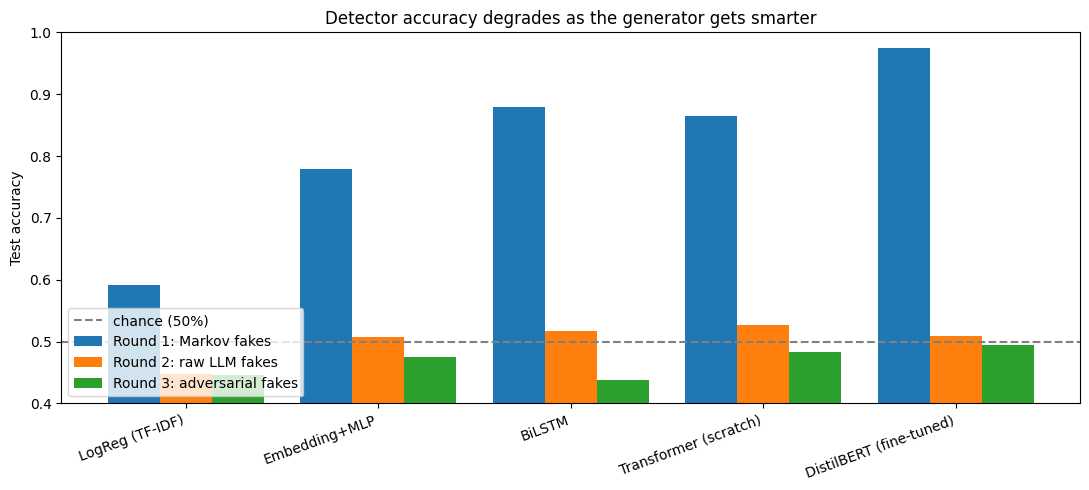

✓ Saved comparison_3rounds.png


In [13]:
import matplotlib.pyplot as plt

names = df["classifier"].tolist()
markov_v = df["round1_markov"].fillna(0).tolist()
llm_v    = df["round2_llm_raw"].fillna(0).tolist()
adv_v    = df["round3_adversarial"].fillna(0).tolist()

x = np.arange(len(names))
w = 0.27
fig, ax = plt.subplots(figsize=(11, 5))
ax.bar(x - w, markov_v, w, label="Round 1: Markov fakes")
ax.bar(x,     llm_v,    w, label="Round 2: raw LLM fakes")
ax.bar(x + w, adv_v,    w, label="Round 3: adversarial fakes")
ax.axhline(0.5, color="gray", linestyle="--", label="chance (50%)")
ax.set_ylim(0.4, 1.0)
ax.set_ylabel("Test accuracy")
ax.set_title("Detector accuracy degrades as the generator gets smarter")
ax.set_xticks(x)
ax.set_xticklabels(names, rotation=20, ha="right")
ax.legend(loc="lower left")
plt.tight_layout()
plt.savefig("comparison_3rounds.png", dpi=150)
plt.show()
print("✓ Saved comparison_3rounds.png")

## Step 8 — Check

The expected pattern (left to right per classifier):

- **Round 1 (Markov)**: highest accuracy —> Markov fakes have obvious artifacts
- **Round 2 (raw LLM)**: lower —> LLM fakes are more fluent
- **Round 3 (adversarial)**: lowest —> these are by construction the LLM fakes that fool our best classifier

